Dataset : https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
import sklearn as sk
import scipy as sc
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import kaggle

In [2]:
kaggle.api.authenticate()
kaggle.api.dataset_download_files('uciml/default-of-credit-card-clients-dataset', path='./data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset


In [3]:
df_true = pd.read_csv("./data/UCI_Credit_Card.csv") #Import
df = df_true.copy(deep=True)

In [4]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Zeroes: 54
After: 0


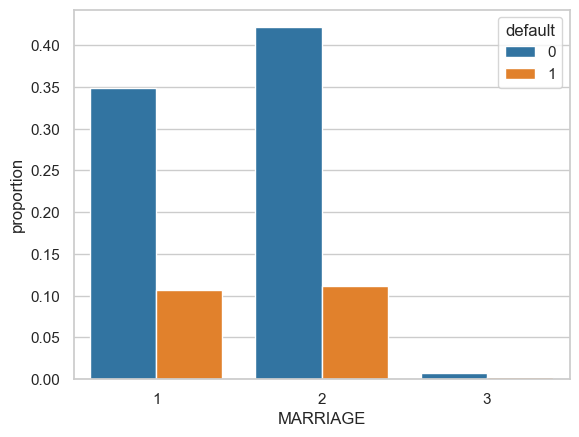

In [5]:
print( "Zeroes:", (df_true["MARRIAGE"] == 0).sum() ) #Total 0's in marriage
m_status = sorted(df["MARRIAGE"].unique()) #1 - married, 2 - single, 3 - other
z_ids = df["ID"][df["MARRIAGE"] == 0].index #Columns with 0's
df.loc[df["MARRIAGE"] == 0] = 3 #Replace 0's with 3
print("After:", (df["MARRIAGE"] == 0).sum())
df = df.rename(columns= {"default.payment.next.month" : "default"}) #Rename default column

df = df[ (df["default"].isin([True, False]) ) ] #Only T/F
sns.set_style("whitegrid")
sns.set_context("notebook")
sns.color_palette("Paired")

df_small = df[:100] #For testing
sns.countplot(df, x="MARRIAGE", hue="default", stat='proportion');

In [6]:
table = pd.crosstab(df['MARRIAGE'], df['default']) #Cross table
chi2, p, dof, expected = sc.stats.chi2_contingency(table)
print(f"Chi2 = {chi2:.3f}, p-value = {p:.3f}") #Chi-square test to check correlation (>2 samples)
#Very small p-value, so marriage status is correlated with default

Chi2 = 30.446, p-value = 0.000


In [7]:
"""
Marriage is categorical, so for numerical methods like logistic regression
we encode it numerically based on the chance of default, so model can learn
more effectively
"""

probs = table[1] / (table[1] + table[0]) #Probability
tuples = list(zip(probs.values, probs.index))
tuples = sorted(tuples, reverse=True)
labels = [3, 2, 1]
vals = dict(zip(labels, [t[1] for t in tuples]))
print("New labels:", vals)
df["MARRIAGE"] = df["MARRIAGE"].replace(vals) #Replacing values of marriage

#Using dummy enc to modify gender (1 - male, 2 - female)
encoded = pd.get_dummies(df['SEX'], prefix='SEX')
df = df.drop(columns='SEX').join(encoded)
df = df.rename(columns={"SEX_1" : "SEX_M", "SEX_2" : "SEX_F"})
df = df.drop(columns= [df.columns[-1]]) #Leaving only sex_m column

New labels: {3: 3, 2: 1, 1: 2}


In [8]:
#EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
print( (df["EDUCATION"] == 0).sum() )
df["EDUCATION"] = df["EDUCATION"].replace({5 : 4, 6 : 4})
df = df[(df["EDUCATION"]) != 0] #Drop zeroes
print(df["EDUCATION"].unique())
df["EDUCATION"] = 4 - df["EDUCATION"] #Reverse scale (0-other, 3-graduate school)

14
[2 1 3 4]


In [9]:
"""
We use np.polyfit to estimate the slope from payment delays,
this will help our model to see the repayment trend
"""

cols = df.columns[5:11] #PAY_X Columns
df[cols] = df[cols].replace({-1: 0, -2: 0}) #Replace -1, -2 by 0
cleaned = pd.DataFrame()
cleaned["delay_count"] = (df[cols] > 0).sum(axis=1)
cleaned["last"] = df[cols[0]]
cleaned["max"] = (df[cols].max(axis=1)).astype(int)
x_cord = np.linspace(1, len(cols), len(cols))

cleaned['pay_slope'] = df[cols].apply(
    lambda x: np.polyfit(x_cord, x.values, 1)[0],
    axis=1
)

df = pd.concat([df, cleaned], axis=1)
df = df.drop(columns=cols)

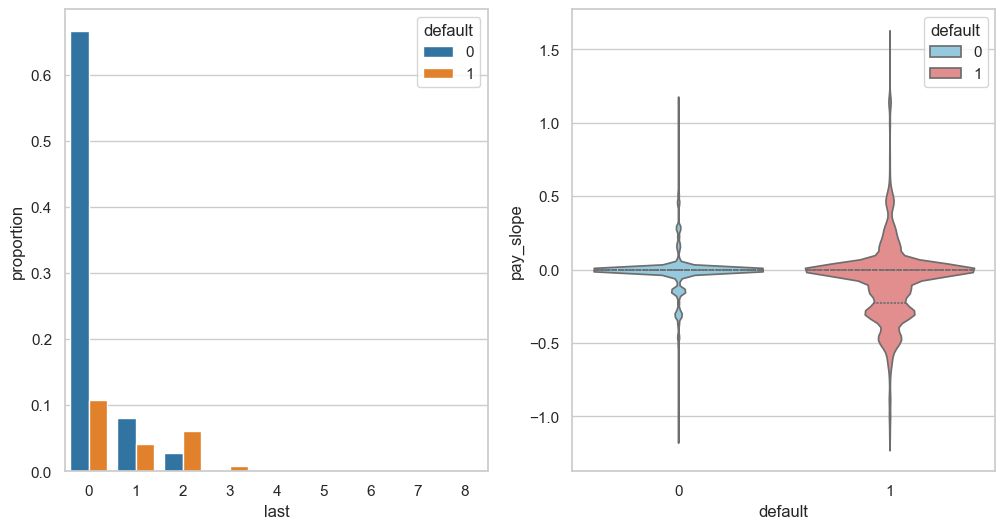

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(df, x="last", hue="default", stat='proportion', ax=axes[0]);
sns.violinplot(x='default', y='pay_slope', hue="default", data=df,
               width=0.8, density_norm="width", inner="quart", 
                palette=['skyblue', 'lightcoral'], ax=axes[1]
);

Motivation:

Recent repayment behavior is expected to contain the most relevant information
about a client’s current financial status.
Rather than relying on average repayment measures, we consider the repayment
slope as it captures the direction and estimates the magnitude of changes in payment behavior.

Assumptions:

We assume that default rate is associated with repayment delays and instability.

Conclusions:

Proportion of defaulted customers is correlated with repayment delay in the last month.
Defaulted customers have extreme and unstable graphic, which implies abrupt changes in repayment behaviour.
This suggests that volatility and abrupt trend shifts rather than direction alone are strong inidcators of default

In [11]:
bills = df.columns[5:11] #BILL_AMT
pays = df.columns[11:17] #PAY_AMT

print(df[pays].isna().sum())
print(df[bills].isna().sum())

PAY_AMT1    0
PAY_AMT2    0
PAY_AMT3    0
PAY_AMT4    0
PAY_AMT5    0
PAY_AMT6    0
dtype: int64
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
dtype: int64


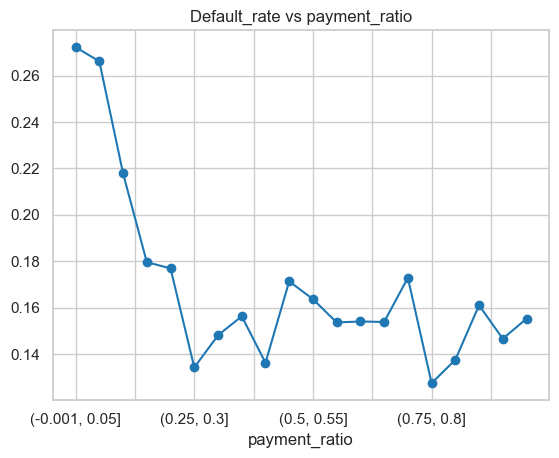

In [12]:
cleaned["payment_ratio"] = df[pays].sum(axis=1) / (df[bills].sum(axis = 1))
infs = (cleaned["payment_ratio"] > 1) | (cleaned["payment_ratio"] < 0)
cleaned.loc[infs, "payment_ratio"] = 1 #Replace inf's and negative numbers
cleaned["default"] = df["default"]
bins = pd.cut(cleaned["payment_ratio"], bins=20)

default_rate = ( cleaned.groupby(bins, observed=False)["default"].mean() )
default_rate.plot(marker="o");
plt.title("Default_rate vs payment_ratio");

Motivation: 

Borrowers who repeatedly take on new debt in order to service existing
obligations are at increased risk of default. In addition, some customers may accumulate credit without a clear repayment
strategy, leading to persistently low repayment levels.

Assumptions:

We assume that a low overall payment ratio is a strong indicator
of elevated default risk, as it reflects sustained underpayment relative
to debts or poor payment behaviour.

Conclusions:

For very low payment_ratios default rate decreases sharply, showing that borrowers that make minimal payments are more likely to default. However beyond some threshold default rate stabilizes

In [ ]:
"""
To preserve the trend we calculate the cumulative ratio between pays and bills,
then fit the poly using np.polyfit
"""

cum_pay = np.cumsum(df[pays].values, axis=1) #Cumulative sum of pays
cum_bill = np.cumsum(df[bills].values, axis=1)


cum_ratio = cum_pay / (cum_bill + 1); #Cumulative ratio, avoid inf if possible
cum_ratio = np.clip(cum_ratio, 0, 5)


cleaned["last_ratio"] = cum_ratio[:, -1]
cleaned["delta_ratio"] = cum_ratio[:, -1] - cum_ratio[:, 0]
cleaned["std_ratio"] = cum_ratio.std(axis=1) #Std of ratio
delta = cum_ratio[:, 1:] - cum_ratio[:, :5]
cleaned["max_jump"] = delta.max(axis=1) # Max (Ratio{i} - Ratio{i-1})

temp = np.apply_along_axis(
    lambda x: np.polyfit(x_cord, x, 1),
    arr=cum_ratio, axis=1
)
cleaned["cum_slope"] = temp[:, 1] #Slope

temp = np.apply_along_axis(
    lambda x: np.polyfit(x_cord[3:], x[3:], 1),
    arr=cum_ratio, axis=1
)
cleaned["last_3_slope"] = temp[:, 1] #Slope


C:\Users\Alim\AppData\Local\Temp\ipykernel_12792\1428059395.py:10: RuntimeWarning: divide by zero encountered in divide
  cum_ratio = cum_pay / (cum_bill + 1); #Cumulative ratio, avoid inf if possible
C:\Users\Alim\AppData\Local\Temp\ipykernel_12792\1428059395.py:10: RuntimeWarning: invalid value encountered in divide
  cum_ratio = cum_pay / (cum_bill + 1); #Cumulative ratio, avoid inf if possible


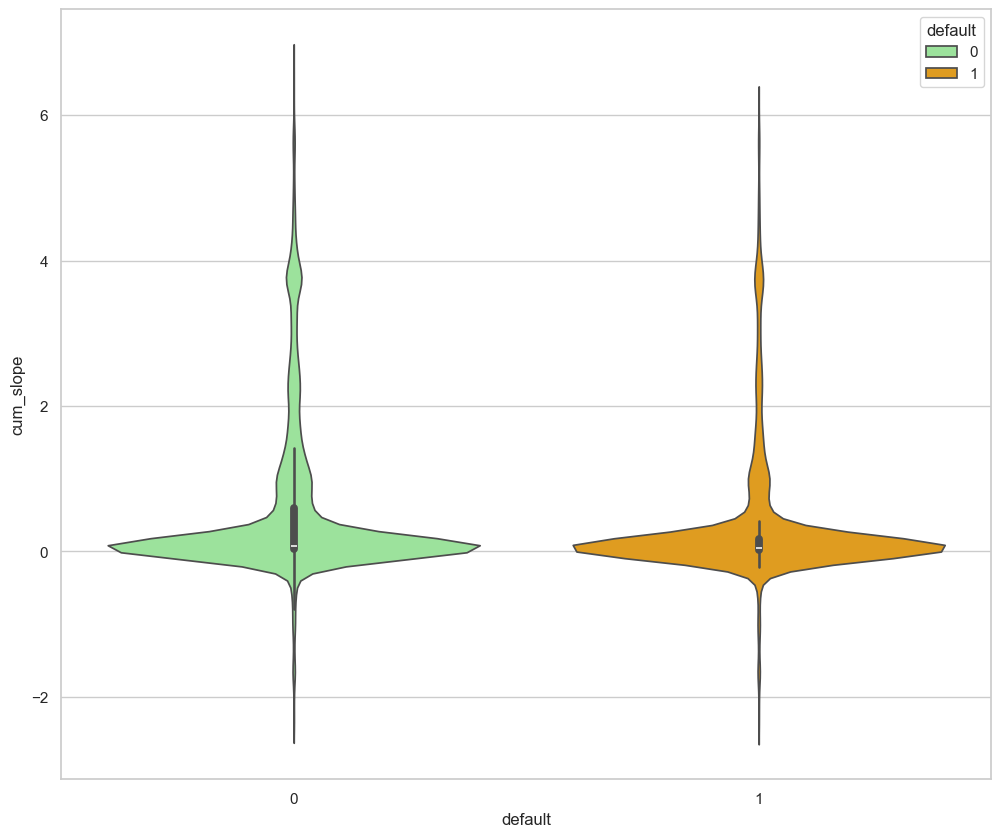

In [14]:
fig, axes = plt.subplots(figsize=(12, 10))

sns.violinplot(x='default', y='cum_slope', hue="default", data=cleaned,
               width=0.8, density_norm="width", 
               palette=['lightgreen', 'orange'], ax=axes
);
plt.show()

Motivation:

Some borrowers may take extended breaks in repaying their debt due to
temporary financial instability or job-related income patterns.
As a result, short-term repayment features may fail to capture meaningful behavioral patterns.

Assumptions:

We assume that cumulative repayment behavior relative to debt size
is more informative than absolute payment or balance levels.
Specifically, the linear trend of the cumulative payment-to-bill ratio
can capture whether a customer is gradually falling behind or catching up
with accumulated debt over time.

Conclusions:

The figure shows that non-defaulted customers are significantly more likely
to exhibit a positive repayment trend, while defaulted customers tend to
display flat or negative trends, indicating worsening repayment behavior.

In [15]:
print(df.columns)
target_columns = ["last_ratio", "delta_ratio", "std_ratio", "max_jump", "cum_slope", "last_3_slope"]
df = df.drop(columns = pays)
df = df.drop(columns = bills)

df = pd.concat([df, cleaned[target_columns]])

print(df.columns)

df.to_csv("./data/processed_data.csv", encoding="utf-8", index=False)

Index(['ID', 'LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'AGE', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default', 'SEX_M', 'delay_count', 'last', 'max', 'pay_slope'],
      dtype='object')
Index(['ID', 'LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'AGE', 'default', 'SEX_M',
       'delay_count', 'last', 'max', 'pay_slope', 'last_ratio', 'delta_ratio',
       'std_ratio', 'max_jump', 'cum_slope', 'last_3_slope'],
      dtype='object')


## Summary
Payment volatility is a stronger indicator than absolute repayment level

Cumulative ratios stabilize default probability after a threshold

Engineered features will be used for downstream modeling